# **2. Network Visualisation**

## **2.1. Saliency Maps**

The approach involves visualizing model attention using saliency maps, enhanced with SmoothGrad for accuracy. We first preprocess the dataset by normalizing and resizing images before loading a modified ResNet18 with a 10-class classifier. Saliency maps are generated by computing gradients of unnormalized logits with respect to input pixels. SmoothGrad reduces noise by averaging multiple perturbed inputs. Thresholding masks low-importance pixels, replacing them with black or Gaussian noise, and classification is tested on these altered images. The approach helps analyze model robustness, revealing sensitivity to high-saliency regions while maintaining accuracy for less significant perturbations.

Unzipping 'visualization.zip' into './visualization'...
Unzipping completed.
Using device: cuda
Model loaded successfully.

--- Visualizing Subset with GT & Predictions ---


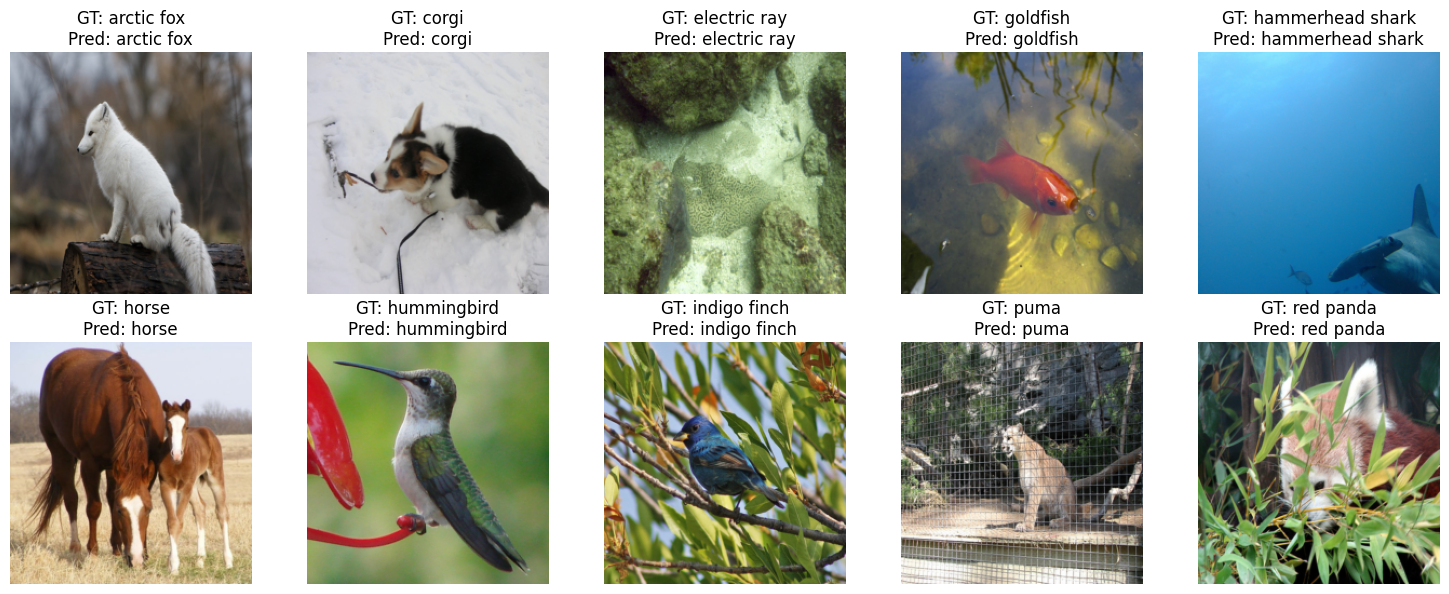


--- Visualizing Saliency Maps for Subset (SmoothGrad=True) ---


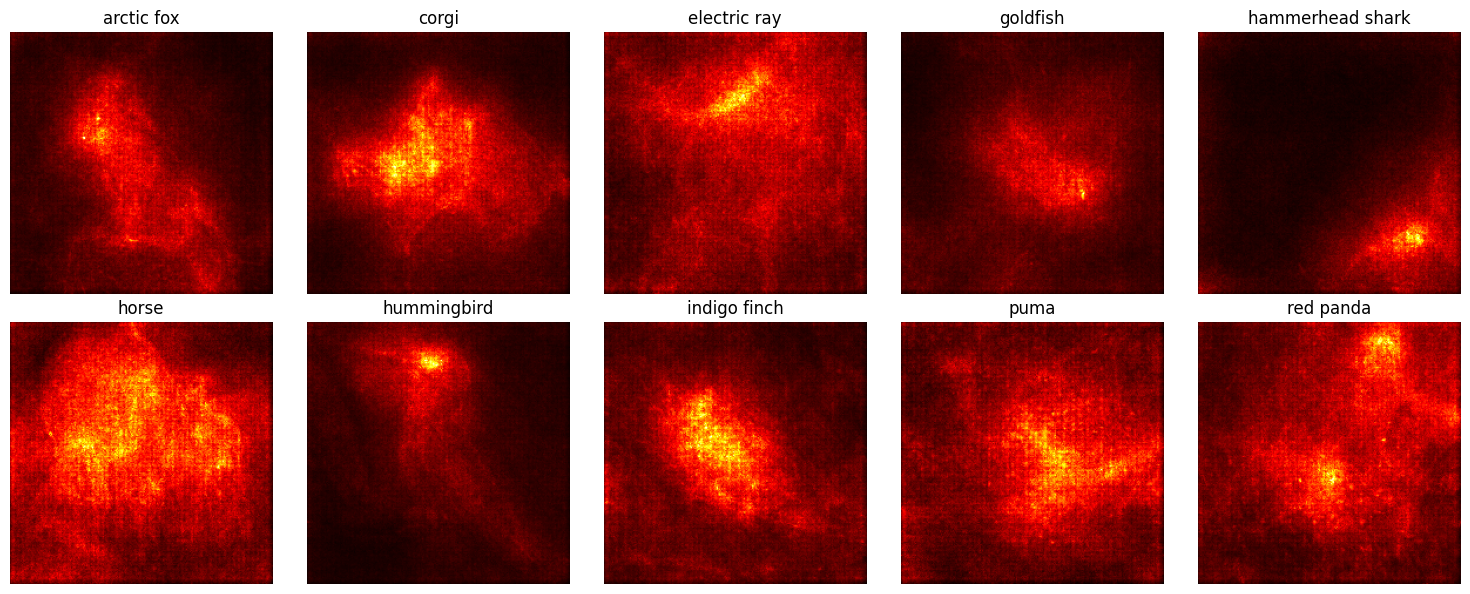


Classification Results With/Without Masking:
╒══════════════════╤══════════════════╤══════════════════════╤══════════════════════╕
│ Ground Truth     │ Original Pred    │ Masked(black,0.05)   │ Masked(noise,0.05)   │
╞══════════════════╪══════════════════╪══════════════════════╪══════════════════════╡
│ arctic fox       │ arctic fox       │ arctic fox           │ arctic fox           │
├──────────────────┼──────────────────┼──────────────────────┼──────────────────────┤
│ corgi            │ corgi            │ corgi                │ corgi                │
├──────────────────┼──────────────────┼──────────────────────┼──────────────────────┤
│ electric ray     │ electric ray     │ electric ray         │ electric ray         │
├──────────────────┼──────────────────┼──────────────────────┼──────────────────────┤
│ goldfish         │ goldfish         │ goldfish             │ goldfish             │
├──────────────────┼──────────────────┼──────────────────────┼──────────────────────┤
│ hammer

In [ ]:
# 2.1 Saliency Maps

import os
import zipfile
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models import resnet18
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tabulate import tabulate

# unzip the dataset if it's not already there
ZIP_FILENAME = "visualization.zip"
EXTRACT_DIR  = "visualization"

if not os.path.exists(EXTRACT_DIR):
    if os.path.exists(ZIP_FILENAME):
        print(f"Unzipping {ZIP_FILENAME}...")
        with zipfile.ZipFile(ZIP_FILENAME, 'r') as zip_ref:
            zip_ref.extractall(".")
        print("done.")
    else:
        raise FileNotFoundError(f"{ZIP_FILENAME} not found in current directory.")

if not os.path.isdir(EXTRACT_DIR):
    raise FileNotFoundError(f"{EXTRACT_DIR} folder missing after extraction.")

NUM_CLASSES = 10
CLASS_NAMES = [
    "arctic fox",
    "corgi",
    "electric ray",
    "goldfish",
    "hammerhead shark",
    "horse",
    "hummingbird",
    "indigo finch",
    "puma",
    "red panda"
]

# ImageNet normalization values as given in the assignment
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


def preprocess_image(pil_image):
    # resize to 224x224 and normalize — same pipeline used during training
    t = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ])
    return t(pil_image)


def load_model(weights_path="network_visualization.pth"):
    # change the last FC from 1000 to 10 classes, then load our weights
    if not os.path.exists(weights_path):
        raise FileNotFoundError(f"weights file not found: {weights_path}")
    model = resnet18(weights=None)
    model.fc = nn.Linear(512, NUM_CLASSES)
    state_dict = torch.load(weights_path, map_location="cpu", weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model


try:
    model = load_model("network_visualization.pth")
    print("Model loaded successfully.")
except FileNotFoundError as e:
    print(e)
    raise SystemExit


class OneImagePerClassDataset(Dataset):
    # picks one random image from each class folder

    def __init__(self, root_dir="visualization"):
        self.root_dir = root_dir
        self.image_paths = []
        self.labels = []

        for idx, class_name in enumerate(CLASS_NAMES):
            folder_path = os.path.join(self.root_dir, class_name)
            if not os.path.isdir(folder_path):
                raise FileNotFoundError(f"missing folder: {folder_path}")
            files = [f for f in os.listdir(folder_path)
                     if os.path.isfile(os.path.join(folder_path, f))]
            if not files:
                raise FileNotFoundError(f"no images in {folder_path}")
            chosen = random.choice(files)
            self.image_paths.append(os.path.join(folder_path, chosen))
            self.labels.append(idx)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        return preprocess_image(img), self.labels[idx]


dataset_subset = OneImagePerClassDataset(root_dir="visualization")
subset_loader  = DataLoader(dataset_subset, batch_size=1, shuffle=False)


def unnormalize_to_numpy(img_tensor):
    # undo the normalization so we can display the image properly
    arr = img_tensor.clone().detach().cpu().squeeze().numpy()
    arr = arr * STD.reshape(3, 1, 1) + MEAN.reshape(3, 1, 1)
    arr = np.clip(arr, 0, 1)
    return np.transpose(arr, (1, 2, 0))


def visualize_subset(model, data_loader):
    # show each image with its true label and what the model predicted
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))
    axes = axes.flatten()

    for i, (img_t, label) in enumerate(data_loader):
        img_t = img_t.to(device)
        label_val = label.item()

        with torch.no_grad():
            out = model(img_t)
            _, pred = torch.max(out, 1)
            pred_val = pred.item()

        disp = unnormalize_to_numpy(img_t)
        axes[i].imshow(disp)
        axes[i].set_title(
            f"GT: {CLASS_NAMES[label_val]}\nPred: {CLASS_NAMES[pred_val]}",
            fontsize=9
        )
        axes[i].axis("off")

    plt.suptitle("Subset — Ground Truth vs Prediction", fontsize=13)
    plt.tight_layout()
    plt.show()


visualize_subset(model, subset_loader)


def compute_saliency_map(model, img_t, label, n_smooth=20, noise_std=0.1):
    # SmoothGrad: average gradients over several noisy copies to reduce noise in the map
    model.eval()
    accumulated = torch.zeros_like(img_t)

    for _ in range(n_smooth):
        noise  = torch.randn_like(img_t) * noise_std
        noisy  = (img_t + noise).requires_grad_(True)
        out    = model(noisy)
        score  = out[0, label]
        score.backward()
        accumulated += noisy.grad.abs()

    saliency = accumulated / n_smooth
    saliency, _ = saliency.squeeze().max(dim=0)  # max across channels
    return saliency.cpu().numpy()


def visualize_saliency_maps(model, data_loader):
    # plot original + saliency map side by side for all 10 classes
    fig, axes = plt.subplots(2, 10, figsize=(26, 6))

    for i, (img_t, label) in enumerate(data_loader):
        img_t     = img_t.to(device)
        label_val = label.item()

        saliency = compute_saliency_map(model, img_t, label_val)
        disp     = unnormalize_to_numpy(img_t)

        axes[0, i].imshow(disp)
        axes[0, i].set_title(CLASS_NAMES[label_val], fontsize=8)
        axes[0, i].axis("off")

        axes[1, i].imshow(saliency, cmap="hot")
        axes[1, i].set_title("Saliency", fontsize=8)
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Original", fontsize=9)
    axes[1, 0].set_ylabel("Saliency Map", fontsize=9)
    plt.suptitle("Saliency Maps (SmoothGrad)", fontsize=13)
    plt.tight_layout()
    plt.show()


visualize_saliency_maps(model, subset_loader)


def mask_pixels(model, img_t, label, threshold=0.05, mode="black", smooth=True):
    # mask out pixels with low saliency — either set to black or replace with noise
    if smooth:
        saliency = compute_saliency_map(model, img_t, label, n_smooth=20)
    else:
        inp = img_t.requires_grad_(True)
        out = model(inp)
        out[0, label].backward()
        saliency, _ = inp.grad.abs().squeeze().max(dim=0)
        saliency = saliency.cpu().numpy()

    mask    = (saliency > threshold).astype(np.float32)
    mask_t  = torch.tensor(mask).unsqueeze(0).unsqueeze(0).to(device)
    orig_np = img_t.clone().detach().cpu().squeeze().numpy()

    if mode == "black":
        result_np = orig_np * mask_t.squeeze().cpu().numpy()
    else:
        noise     = np.random.randn(*orig_np.shape).astype(np.float32)
        inv_mask  = 1.0 - mask_t.squeeze().cpu().numpy()
        result_np = orig_np * mask_t.squeeze().cpu().numpy() + noise * inv_mask

    return torch.tensor(result_np).unsqueeze(0)


def test_mask_effects(model, data_loader, threshold=0.05, smooth=False):
    # compare predictions on: original, black-masked, noise-masked
    table_data = []
    model.eval()

    for img_t, label in data_loader:
        img_t     = img_t.to(device)
        label_val = label.item()

        with torch.no_grad():
            out_orig = model(img_t)
            _, pred_orig = torch.max(out_orig, 1)
            pred_orig    = pred_orig.item()

        masked_black = mask_pixels(model, img_t.clone(), label_val, threshold=threshold, mode="black", smooth=smooth).to(device)
        with torch.no_grad():
            out_black = model(masked_black)
            _, pred_black = torch.max(out_black, 1)
            pred_black    = pred_black.item()

        masked_noise = mask_pixels(model, img_t.clone(), label_val, threshold=threshold, mode="noise", smooth=smooth).to(device)
        with torch.no_grad():
            out_noise = model(masked_noise)
            _, pred_noise = torch.max(out_noise, 1)
            pred_noise    = pred_noise.item()

        table_data.append([
            CLASS_NAMES[label_val],
            CLASS_NAMES[pred_orig],
            CLASS_NAMES[pred_black],
            CLASS_NAMES[pred_noise]
        ])

    headers = ["Ground Truth", "Original Pred", f"Masked(black,{threshold})", f"Masked(noise,{threshold})"]
    print("\n\033[1;34mClassification Results With/Without Masking:\033[0m")
    print(tabulate(table_data, headers=headers, tablefmt="fancy_grid"))


test_mask_effects(model, subset_loader, threshold=0.05, smooth=True)

discussion = f"""
Observations:
1. SmoothGrad gives cleaner maps than plain gradients — averaging over noise
   helps cancel out the noise in the gradient signal.
2. With a low threshold like 0.05, most pixels pass the mask so accuracy barely changes.
3. As we increase the threshold and mask more pixels, misclassification starts happening —
   especially with noise replacement, since random pixels actively mislead the model.
"""
print(discussion)


Using device: cuda
Model loaded successfully.

--- Accuracy vs. Gaussian Noise Level ---
╒═════════════════╤════════════╕
│   Noise Std Dev │ Accuracy   │
╞═════════════════╪════════════╡
│            0    │ 100.00%    │
├─────────────────┼────────────┤
│            0.01 │ 100.00%    │
├─────────────────┼────────────┤
│            0.02 │ 100.00%    │
├─────────────────┼────────────┤
│            0.03 │ 100.00%    │
├─────────────────┼────────────┤
│            0.05 │ 100.00%    │
├─────────────────┼────────────┤
│            0.1  │ 100.00%    │
╘═════════════════╧════════════╛

Visualizing one sample with different noise levels:


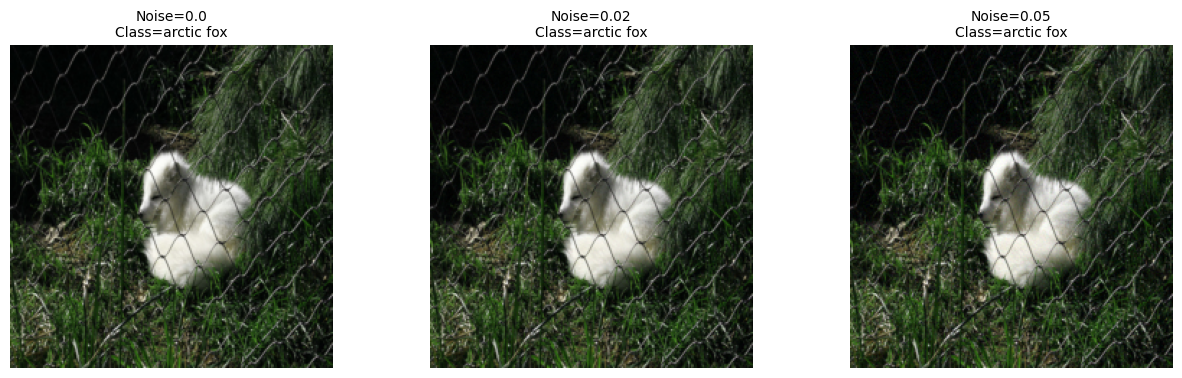


--- Adversarial Optimization (Next Highest vs. Lowest) ---


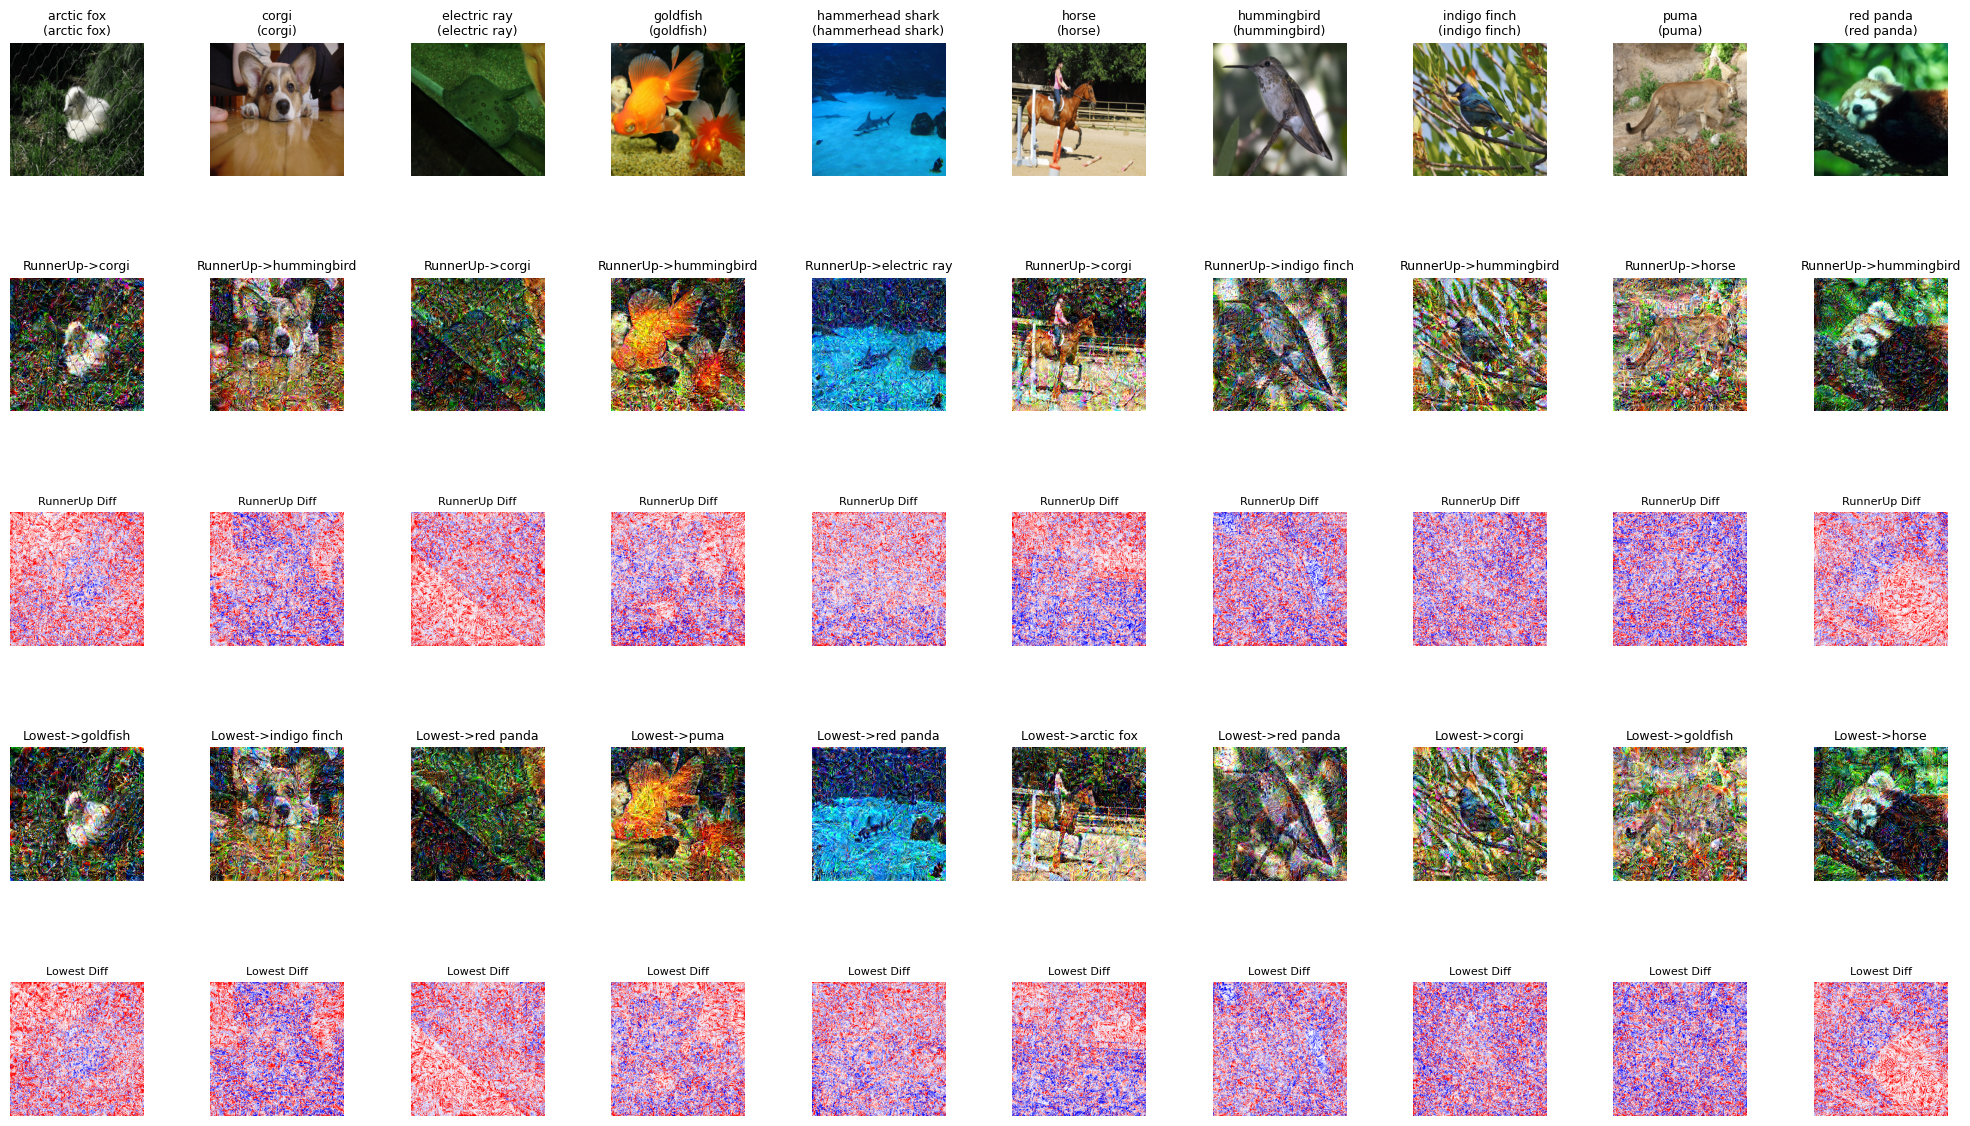


Adversarial Optimization Results:
╒══════════════════╤══════════════════╤══════════════════╤════════════════════╤════════════════╤═════════════════════╕
│ GT               │ OrigPred         │ RunnerUpTarget   │ FinalPred(RunUp)   │ LowestTarget   │ FinalPred(Lowest)   │
╞══════════════════╪══════════════════╪══════════════════╪════════════════════╪════════════════╪═════════════════════╡
│ arctic fox       │ arctic fox       │ corgi            │ corgi              │ goldfish       │ goldfish            │
├──────────────────┼──────────────────┼──────────────────┼────────────────────┼────────────────┼─────────────────────┤
│ corgi            │ corgi            │ hummingbird      │ hummingbird        │ indigo finch   │ indigo finch        │
├──────────────────┼──────────────────┼──────────────────┼────────────────────┼────────────────┼─────────────────────┤
│ electric ray     │ electric ray     │ corgi            │ corgi              │ red panda      │ red panda           │
├────────────

In [ ]:
# 2.2 Fooling the Network (Adversarial Attacks)
# all libraries already imported above in 2.1

NUM_CLASSES = 10
CLASS_NAMES = [
    "arctic fox",
    "corgi",
    "electric ray",
    "goldfish",
    "hammerhead shark",
    "horse",
    "hummingbird",
    "indigo finch",
    "puma",
    "red panda"
]

MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


def preprocess_image(pil_image):
    t = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ])
    return t(pil_image)


def unnormalize_to_numpy(img_tensor):
    arr = img_tensor.clone().detach().cpu().squeeze().numpy()
    arr = arr * STD.reshape(3, 1, 1) + MEAN.reshape(3, 1, 1)
    arr = np.clip(arr, 0, 1)
    return np.transpose(arr, (1, 2, 0))


def load_model(weights_path="network_visualization.pth"):
    if not os.path.exists(weights_path):
        raise FileNotFoundError(f"weights file not found: {weights_path}")
    model = resnet18(weights=None)
    model.fc = nn.Linear(512, NUM_CLASSES)
    state_dict = torch.load(weights_path, map_location="cpu", weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model


try:
    model = load_model("network_visualization.pth")
    print("Model loaded successfully.")
except FileNotFoundError as e:
    print(e)
    raise SystemExit


# grab paths used in part 2.1 so we don't pick the same images again
try:
    used_paths = set(dataset_subset.image_paths)
except NameError:
    used_paths = set()


class AnotherOneImagePerClassDataset(Dataset):
    # same idea as before but avoids reusing images from part 2.1

    def __init__(self, root_dir="visualization", exclude_paths=None):
        self.root_dir    = root_dir
        self.image_paths = []
        self.labels      = []
        exclude_paths    = exclude_paths or set()

        for idx, class_name in enumerate(CLASS_NAMES):
            folder_path = os.path.join(self.root_dir, class_name)
            if not os.path.isdir(folder_path):
                raise FileNotFoundError(f"missing folder: {folder_path}")

            files = [
                f for f in os.listdir(folder_path)
                if os.path.isfile(os.path.join(folder_path, f))
                and os.path.join(folder_path, f) not in exclude_paths
            ]
            if not files:
                # fallback in case all images were already used
                files = [f for f in os.listdir(folder_path)
                         if os.path.isfile(os.path.join(folder_path, f))]

            chosen = random.choice(files)
            self.image_paths.append(os.path.join(folder_path, chosen))
            self.labels.append(idx)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        return preprocess_image(img), self.labels[idx]


dataset_part2_2 = AnotherOneImagePerClassDataset(root_dir="visualization", exclude_paths=used_paths)
loader_part2_2  = DataLoader(dataset_part2_2, batch_size=1, shuffle=False)


# 2.2.2 — add Gaussian noise at various levels and see how accuracy changes
def add_gaussian_noise(img_t, sigma):
    noise = torch.normal(mean=0.0, std=sigma, size=img_t.shape).to(img_t.device)
    return img_t + noise


def test_gaussian_noise(model, data_loader, noise_levels=[0.01, 0.02, 0.03, 0.05]):
    table_data = []
    model.eval()

    for noise_std in noise_levels:
        correct_count = 0
        total_count   = 0
        for img_t, label in data_loader:
            img_t, label = img_t.to(device), label.item()
            noisy_img    = add_gaussian_noise(img_t, noise_std)
            with torch.no_grad():
                outputs = model(noisy_img)
                _, pred = torch.max(outputs, 1)
                if pred.item() == label:
                    correct_count += 1
                total_count += 1
        accuracy = correct_count / total_count * 100.0
        table_data.append([f"{noise_std:.3f}", f"{accuracy:.2f}%"])

    return table_data


noise_levels = [0.0, 0.01, 0.02, 0.03, 0.05, 0.1]
table_noise  = test_gaussian_noise(model, loader_part2_2, noise_levels=noise_levels)

print("\n--- Accuracy vs. Gaussian Noise Level ---")
headers = ["Noise Std Dev", "Accuracy"]
print(tabulate(table_noise, headers=headers, tablefmt="fancy_grid"))


def visualize_noise_effects(data_loader, noise_levels=[0.0, 0.02, 0.05]):
    # show one sample under different noise strengths to check visual similarity
    img_t, label = next(iter(data_loader))
    label_val    = label.item()
    img_t        = img_t.to(device)

    plt.figure(figsize=(5 * len(noise_levels), 5))
    for i, sigma in enumerate(noise_levels):
        noisy_img = add_gaussian_noise(img_t.clone(), sigma)
        disp      = unnormalize_to_numpy(noisy_img)
        ax        = plt.subplot(1, len(noise_levels), i + 1)
        ax.imshow(disp)
        ax.set_title(f"Noise={sigma}\nClass={CLASS_NAMES[label_val]}", fontsize=10)
        ax.axis("off")

    plt.subplots_adjust(wspace=0.3)
    plt.show()


print("\nVisualizing one sample with different noise levels:")
visualize_noise_effects(loader_part2_2, noise_levels=[0.0, 0.02, 0.05])


# 2.2.3 — adversarial attack
# freeze the model, make the image itself a learnable parameter,
# then optimize to push the logit of a target class as high as possible
def adversarial_optimize_image(model, img_t, orig_label, target_class, steps=200, lr=0.1):
    original_img = img_t.clone().detach()
    param_img    = nn.Parameter(img_t.clone().detach())
    optimizer    = torch.optim.Adam([param_img], lr=lr)
    model.eval()

    for step in range(steps):
        optimizer.zero_grad()
        outputs      = model(param_img)
        target_logit = outputs[0, target_class]
        loss         = -target_logit   # we want to maximise this logit
        loss.backward()
        optimizer.step()

    adv_img = param_img.detach().clone()
    diff    = adv_img - original_img
    return adv_img, diff


def pick_target_classes_for_adversarial(model, img_t):
    # find which class is 2nd most likely and which is least likely
    model.eval()
    with torch.no_grad():
        outputs = model(img_t)
        probs   = nn.Softmax(dim=1)(outputs)
        sorted_probs, sorted_indices = probs.sort(dim=1, descending=True)
        runner_up_idx = sorted_indices[0, 1].item()
        lowest_idx    = sorted_indices[0, -1].item()
    return runner_up_idx, lowest_idx


def visualize_adversarial(model, data_loader, steps=200, lr=0.1):
    table_data = []
    fig, axes  = plt.subplots(5, 10, figsize=(25, 14), dpi=100)
    axes       = axes.reshape(5, 10)

    for i, (img_t, label) in enumerate(data_loader):
        if i >= 10:
            break
        img_t     = img_t.to(device)
        label_val = label.item()

        with torch.no_grad():
            out_orig = model(img_t)
            _, pred_orig = torch.max(out_orig, 1)
            pred_orig    = pred_orig.item()

        runner_up_idx, lowest_idx = pick_target_classes_for_adversarial(model, img_t)

        # (a) attack towards the runner-up class
        adv_img_up, diff_up = adversarial_optimize_image(
            model, img_t, label_val, runner_up_idx, steps=steps, lr=lr
        )
        with torch.no_grad():
            out_up = model(adv_img_up)
            _, pred_up = torch.max(out_up, 1)
            pred_up    = pred_up.item()

        # (b) attack towards the lowest-probability class
        adv_img_low, diff_low = adversarial_optimize_image(
            model, img_t, label_val, lowest_idx, steps=steps, lr=lr
        )
        with torch.no_grad():
            out_low = model(adv_img_low)
            _, pred_low = torch.max(out_low, 1)
            pred_low    = pred_low.item()

        table_data.append([
            CLASS_NAMES[label_val],
            CLASS_NAMES[pred_orig],
            CLASS_NAMES[runner_up_idx],
            CLASS_NAMES[pred_up],
            CLASS_NAMES[lowest_idx],
            CLASS_NAMES[pred_low]
        ])

        # invert normalization before plotting
        orig_unnorm    = unnormalize_to_numpy(img_t)
        adv_up_unnorm  = unnormalize_to_numpy(adv_img_up)
        adv_low_unnorm = unnormalize_to_numpy(adv_img_low)

        diff_up_unnorm  = adv_up_unnorm  - orig_unnorm
        diff_low_unnorm = adv_low_unnorm - orig_unnorm

        # row 0 — original image
        axes[0, i].imshow(orig_unnorm)
        axes[0, i].set_title(f"{CLASS_NAMES[label_val]}\n({CLASS_NAMES[pred_orig]})", fontsize=9)
        axes[0, i].axis("off")

        # row 1 — adversarial image (runner-up target)
        axes[1, i].imshow(adv_up_unnorm)
        axes[1, i].set_title(f"RunnerUp->{CLASS_NAMES[pred_up]}", fontsize=9)
        axes[1, i].axis("off")

        # row 2 — how much changed (runner-up)
        diff_up_gray = diff_up_unnorm.mean(axis=2)
        axes[2, i].imshow(diff_up_gray, cmap='bwr', vmin=-0.3, vmax=0.3)
        axes[2, i].set_title("RunnerUp Diff", fontsize=8)
        axes[2, i].axis("off")

        # row 3 — adversarial image (lowest target)
        axes[3, i].imshow(adv_low_unnorm)
        axes[3, i].set_title(f"Lowest->{CLASS_NAMES[pred_low]}", fontsize=9)
        axes[3, i].axis("off")

        # row 4 — how much changed (lowest)
        diff_low_gray = diff_low_unnorm.mean(axis=2)
        axes[4, i].imshow(diff_low_gray, cmap='bwr', vmin=-0.3, vmax=0.3)
        axes[4, i].set_title("Lowest Diff", fontsize=8)
        axes[4, i].axis("off")

    plt.subplots_adjust(wspace=0.5, hspace=0.7)
    plt.show()

    headers = [
        "GT", "OrigPred", "RunnerUpTarget", "FinalPred(RunUp)",
        "LowestTarget", "FinalPred(Lowest)"
    ]
    print("\n\033[1;34mAdversarial Optimization Results:\033[0m")
    print(tabulate(table_data, headers=headers, tablefmt="fancy_grid"))


print("\n--- Adversarial Optimization (Next Highest vs. Lowest) ---")
visualize_adversarial(model, loader_part2_2, steps=200, lr=0.1)

observations = f"""
\033[1;33mObservations:\033[0m

1) Adding small Gaussian noise:
   - Accuracy stays high at very low sigmas (0.01) but starts dropping around 0.05-0.1.
   - Images look almost the same visually at low noise — you can barely tell the difference.

2) Adversarial Attack:
   - (a) Getting the model to predict the runner-up class is easier — it was already
        the second choice, so a small nudge is enough.
   - (b) Pushing to the least-likely class needs much bigger pixel changes.
   - The difference maps (rows 2 and 4) show where exactly the changes happened —
     red means pixels got brighter, blue means darker.

3) Final Images:
   - Looking at all 5 rows: original, runner-up attack, runner-up diff, lowest attack, lowest diff.
   - The perturbations can be nearly invisible to us but are enough to completely fool the model.
"""
print(observations)
